#### Preprocessing and Pipelines

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
music_df = pd.read_csv("C:/Users/Senthil/Downloads/music_clean.csv")

In [4]:
music_df.head()

,Unnamed: 0,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,genre
0,36506,60.0,0.896000,0.726,214547.0,0.177,0.000002,0.1160,-14.824,0.0353,92.934,0.618,1
1,37591,63.0,0.003840,0.635,190448.0,0.908,0.083400,0.2390,-4.795,0.0563,110.012,0.637,1
2,37658,59.0,0.000075,0.352,456320.0,0.956,0.020300,0.1250,-3.634,0.1490,122.897,0.228,1
3,36060,54.0,0.945000,0.488,352280.0,0.326,0.015700,0.1190,-12.020,0.0328,106.063,0.323,1
4,35710,55.0,0.245000,0.667,273693.0,0.647,0.000297,0.0633,-7.787,0.0487,143.995,0.300,1


In [5]:
music_df.dtypes

Unnamed: 0            int64
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
genre                 int64
dtype: object

In [6]:
music_df["genre"]

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: genre, Length: 1000, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
# Create music_dummies
music_dummies = pd.get_dummies(music_df, drop_first=True)

# Print the new DataFrame's shape
print("Shape of music_dummies: {}".format(music_dummies.shape))

Shape of music_dummies: (1000, 13)


Regression with categorical features

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

X = music_dummies.drop("popularity", axis=1).values
y = music_dummies["popularity"].values

ridge = Ridge(alpha=0.2)
kf = KFold(n_splits=6, shuffle=True, random_state=42)
scores = cross_val_score(ridge, X, y, cv=kf, scoring="neg_mean_squared_error")


In [9]:
- scores

array([138.14003044,  81.72741922, 109.52459099,  69.96091079,
        99.77439989, 107.77470329])

In [13]:
rmse = np.mean(np.sqrt(-scores))
print(f"RMSE: {rmse}")
print(f"Standard Deviation of Target array: {np.std(y)}")

RMSE: 9.998909565816527
Standard Deviation of Target array: 14.02156909907019


Dropping Missing Values

In [ ]:
# print out missing values
music_df.isna().sum().sort_values()

Unnamed: 0          0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
genre               0
dtype: int64

In [17]:
# Remove values where less than 5% are missing
music_df = music_df.dropna(subset=["genre", "popularity", "loudness", "liveness", "tempo"])

Pipeline for song genre prediction: I

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNeighborsClassifier(n_neighbors=6)
imputer = SimpleImputer()


# steps for buiding a pipeline
steps = [
    ("imputer", imputer),
    ("knn", knn)
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[90 10]
 [ 6 94]]


Centering and scaling for regression - Target is "loudness"

In [27]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X = music_df.drop("loudness", axis=1).values
y = music_df["loudness"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.5)
scaler = StandardScaler()

steps = [
    ("scaler", scaler),
    ("lasso", lasso)
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# calculate andd print r squared score
print(f"R-squared Score: {pipeline.score(X_test, y_test)}")

R-squared Score: 0.720065318543369


Centering and scaling for classification - Target is "genre"

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

params = {"logreg__C" : np.linspace(0.001, 1.0, 20)}

steps = [
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
]
pipeline = Pipeline(steps)

cv = GridSearchCV(pipeline, params)
cv.fit(X_train, y_train)

print("Best Parameters: ", cv.best_params_)
print("Best Score: ", cv.best_score_)

Best Parameters:  {'logreg__C': np.float64(0.5267894736842105)}
Best Score:  0.9087500000000001


Visualizing regression model performance - Target is "energy"

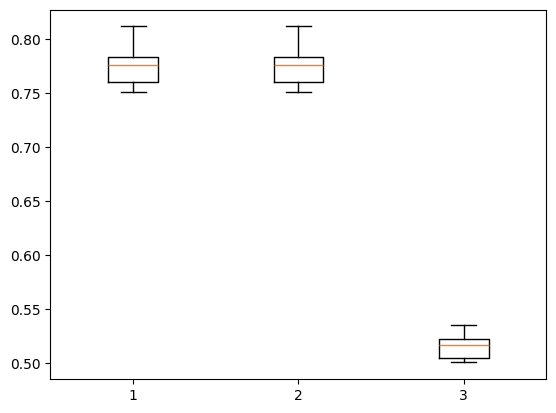

In [37]:
# doing linear regression, ridge and lasso regression 

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline

X = music_df.drop("energy", axis=1).values
y = music_df["energy"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "linear regression" : Pipeline(
        [
            ("scaler", StandardScaler()),
            ("linear_regression",LinearRegression())
        ]
    ),
    "ridge" : Pipeline(
        [
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=0.1))
        ]
    ),
    "lasso" : Pipeline(
        [
            ("scaler", StandardScaler()),
            ("lasso", Lasso(alpha=0.1))
        ]
    )

}

results = []

for name, model in models.items():
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    results.append(cv_scores)

plt.boxplot(results, label=models.keys())
plt.show()

Predicting on the test set

In [39]:
from sklearn.metrics import root_mean_squared_error

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"{name} Test set RMSE: {rmse}")

linear regression Test set RMSE: 0.11135172852418034
ridge Test set RMSE: 0.11135416106606619
lasso Test set RMSE: 0.17329638628819166


Visualizing classification model performanceVisualizing classification model performance

classification problem where the "popularity_above_median" column in the music_df dataset has been created to be binary values, with 1 representing popularity more than or equal to the median for the "popularity" column, and 0 indicating popularity below the median

In [44]:
music_df["popularity_above_median"] = np.where(music_df["popularity"] >= music_df["popularity"].median(), 1, 0)

c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Senthil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://s

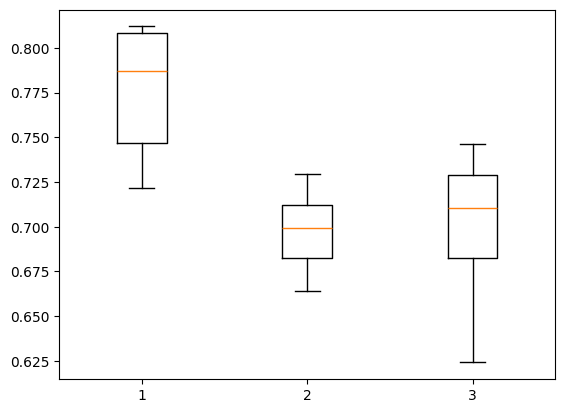

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score

X = music_df.drop(columns=["popularity", "popularity_above_median"], axis=1).values
y = music_df["popularity_above_median"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    "logistic_regression" : LogisticRegression(),
    "knn" : KNeighborsClassifier(),
    "tree" : DecisionTreeClassifier()
}

results = []

for name, model in models.items():
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    results.append(cv_scores)

plt.boxplot(results, label=models.keys())
plt.show()

Pipeline for predicting song popularity

 aim is to find the best parameters and accuracy when predicting song genre

In [50]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split

X = music_df.drop(columns=["popularity_above_median", "popularity"], axis=1).values
y = music_df["popularity_above_median"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

params = {"logreg__solver": ["newton-cg", "saga", "lbfgs"],
         "logreg__C": np.linspace(0.001, 1.0, 10)}

steps = [
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
]

pipeline = Pipeline(steps)

tuning = GridSearchCV(pipeline, params)
tuning.fit(X_train, y_train)

print("Best Parameters : ", tuning.best_params_)
print("Best Score: ", tuning.best_score_)

print("Logistic Regression R-squared score", tuning.score(X_test, y_test))

Best Parameters :  {'logreg__C': np.float64(0.112), 'logreg__solver': 'newton-cg'}
Best Score:  0.8025
Logistic Regression R-squared score 0.815
